In [20]:
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import sys
sys.path.append("../src/")
from mrvis.utils.matplotlib_style import gcolor

filepath = "/home/max/Temp"

all_files = sorted(glob.glob(os.path.join(filepath, "reconnection_rates_step_*.txt")))
number_of_files = len(all_files)


Processing /home/max/Temp/reconnection_rates_step_0001.txt
Processing /home/max/Temp/reconnection_rates_step_0002.txt
Processing /home/max/Temp/reconnection_rates_step_0003.txt
Processing /home/max/Temp/reconnection_rates_step_0004.txt
Processing /home/max/Temp/reconnection_rates_step_0005.txt
Processing /home/max/Temp/reconnection_rates_step_0006.txt
Processing /home/max/Temp/reconnection_rates_step_0007.txt
Processing /home/max/Temp/reconnection_rates_step_0008.txt
Processing /home/max/Temp/reconnection_rates_step_0009.txt
Processing /home/max/Temp/reconnection_rates_step_0010.txt
Processing /home/max/Temp/reconnection_rates_step_0011.txt
Processing /home/max/Temp/reconnection_rates_step_0012.txt
Processing /home/max/Temp/reconnection_rates_step_0013.txt
Processing /home/max/Temp/reconnection_rates_step_0014.txt
Processing /home/max/Temp/reconnection_rates_step_0015.txt
Processing /home/max/Temp/reconnection_rates_step_0016.txt
Processing /home/max/Temp/reconnection_rates_step_0017.t

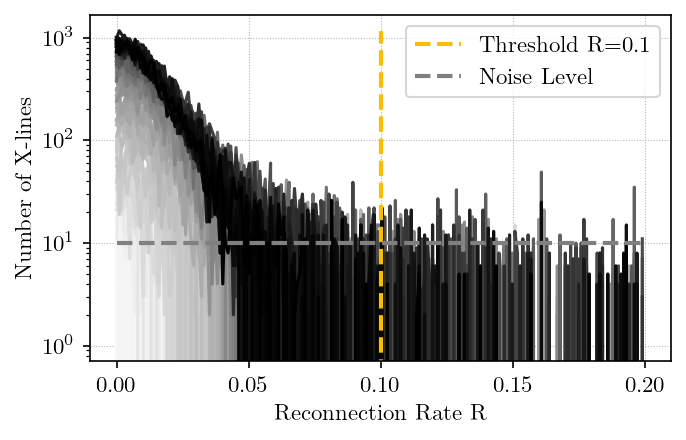

In [21]:

gradient = np.linspace(0.0, 1.0, number_of_files)[::-1]

def plot_histogram(step, datapath, max_reconnection_rate=0.2, bins=200):
    data = np.loadtxt(datapath)
    data = np.copy(data[np.where(data > 0.0)])
    bins = np.linspace(0.0, max_reconnection_rate, bins)
    x, bins = np.histogram(data, bins=bins, density=False)
    plt.plot(bins[:-1], x, linewidth=1.5, color=(gradient[step], gradient[step], gradient[step]))
    return np.max(x)
    # plt.hist(data, bins=bins, density=True, color=(gradient[step], gradient[step], gradient[step], 0.8), label=f"Step {step + 1}")

plt.figure(figsize=(5,3), dpi=150)

max_val = 0.0
for i, datapath in enumerate(all_files):
    print(f"Processing {datapath}")
    max_val_new = plot_histogram(i, datapath)
    if max_val_new > max_val:
        max_val = max_val_new

plt.vlines(0.1, 0.0, max_val, color=gcolor("yellow"), linestyle="--", linewidth=2.0, label="Threshold R=0.1")
plt.hlines(10.0, 0.0, 0.2, color="gray", linestyle="--", linewidth=2.0, label="Noise Level")
plt.yscale("log")
plt.xlabel("Reconnection Rate R")
plt.ylabel("Number of X-lines")
plt.legend()

<Figure size 600x450 with 0 Axes>

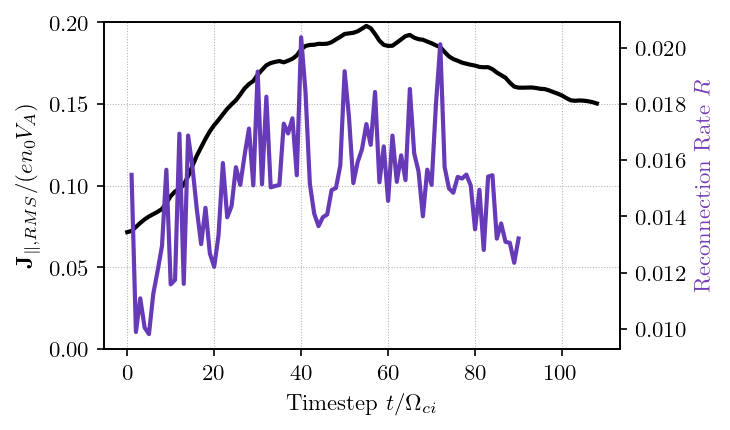

In [22]:
current_density = np.loadtxt("/home/max/Repos/Magnetic-Reconnection-Visualization/data/solar_wind_current_density.dat")

def get_max_reconnection(datapath):
    data = np.loadtxt(datapath)
    data = np.copy(data[np.where(data > 0.0)])
    data = np.copy(data[np.where(data < 10.0)])
    max_r = np.mean(data)
    return max_r

plt.figure(figsize=(4,3), dpi=150)

max_reconnection_rates = []
for i, datapath in enumerate(all_files):
    max_r = get_max_reconnection(datapath)
    max_reconnection_rates.append(max_r)

fig, ax1 = plt.subplots(figsize=(5,3), dpi=150)

ax2 = ax1.twinx()
ax2.plot(np.arange(1, number_of_files + 1), max_reconnection_rates,color=gcolor("violet"), linewidth=2.0)

# ax2.plot(number_of_points[:,0][:-5], number_of_points[:,1][:-5]/1e5, color="#743db4", linewidth=2)
ax1.plot(current_density[:,1], color="black", linewidth=2)

ax1.set_ylim(0,0.2)
ax1.set_xlabel(r"Timestep $t/\Omega_{ci}$")
ax1.set_ylabel(r"$\mathbf{J}_{\|,RMS}/(e n_0 V_A)$", color="black")
ax2.set_ylabel("Reconnection Rate $R$", color="#743db4")
ax2.grid(False)
plt.tight_layout()
# plt.savefig("/home/max/Nextcloud/Bachelor/Media/Plots/num_points_lines.pdf", dpi=300)
plt.show()